In [1]:
from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt
import traceback

from binny.api.nz_tomography import NZTomography


In [2]:
def plot_parent_and_bins(z, nz, bins, *, title="NZTomography", ax=None):
    created = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))
        created = True

    # ax.plot(z, nz, linewidth=2, label="parent n(z)")

    for k in sorted(bins.keys()):
        ax.plot(z, np.asarray(bins[k], float), linewidth=2, label=f"bin {k}")

    ax.set_xlabel("z")
    ax.set_ylabel("n(z)")
    ax.set_title(title)
    ax.legend()

    if created:
        plt.show()


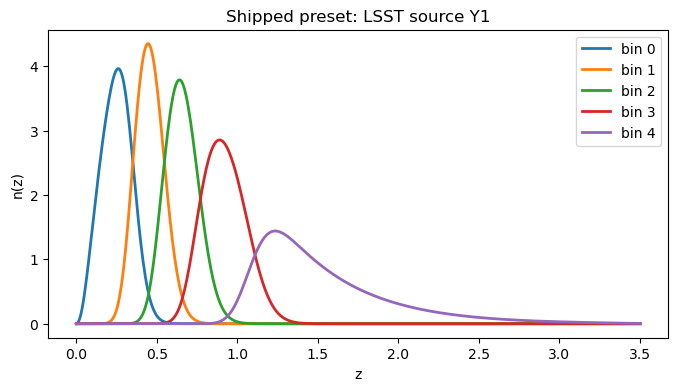

In [3]:
t = NZTomography()

payload = t.build_survey_bins(
    "lsst",            # -> loads lsst_survey_specs.yaml
    role="source",     # or "lens"
    year="1",          # usually string keys
    include_tomo_metadata=True,  # needed for population stats
    include_survey_metadata=True
)

z = payload["z"]
nz = payload["nz"]
bins = payload["bins"]

plot_parent_and_bins(z, nz, bins, title="Shipped preset: LSST source Y1")


In [4]:
shape = t.shape_stats()
pop = t.population_stats()

shape, pop


({'centers': {0: 0.25, 1: 0.46, 2: 0.65, 3: 0.92, 4: 1.53},
  'peaks': {0: {'mode': 0.2595190380761523,
    'mode_height': 3.9639940897252055,
    'num_peaks': 1.0,
    'second_peak_ratio': 0.0},
   1: {'mode': 0.44188376753507014,
    'mode_height': 4.349807591656345,
    'num_peaks': 1.0,
    'second_peak_ratio': 0.0},
   2: {'mode': 0.6382765531062125,
    'mode_height': 3.7889817422707317,
    'num_peaks': 1.0,
    'second_peak_ratio': 0.0},
   3: {'mode': 0.8907815631262526,
    'mode_height': 2.8548613041839035,
    'num_peaks': 1.0,
    'second_peak_ratio': 0.0},
   4: {'mode': 1.2344689378757514,
    'mode_height': 1.4402557667012497,
    'num_peaks': 1.0,
    'second_peak_ratio': 0.0}},
  'per_bin': {0: {'moments': {'mean': 0.25059666568344474,
     'median': 0.25079040055064195,
     'mode': 0.2595190380761523,
     'std': 0.09440905438028623,
     'skewness': 0.1029260409119906,
     'kurtosis': -0.3574827309997284,
     'iqr': 0.13484182636761466,
     'width_68': 0.1960666

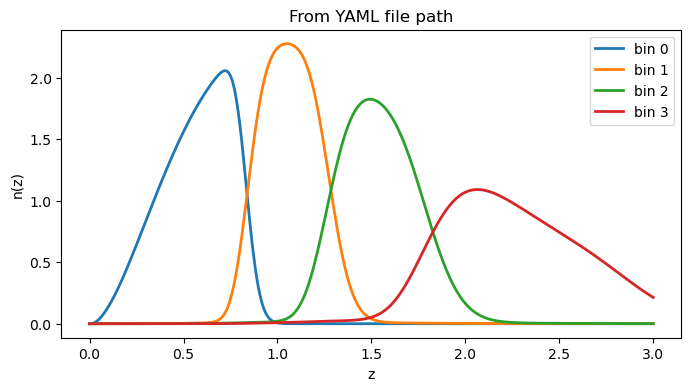

In [5]:
t = NZTomography()

payload = t.build_bins(
    config_file="src/binny/surveys/configs/example_full_photoz.yaml",
    role="source",
    year="1",
    include_tomo_metadata=False,
    include_survey_metadata=True,
)

z, nz, bins = payload["z"], payload["nz"], payload["bins"]
plot_parent_and_bins(z, nz, bins, title="From YAML file path")


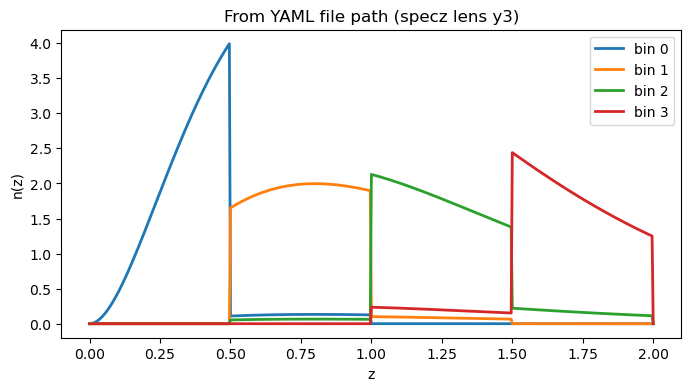

In [6]:
t = NZTomography()

payload = t.build_bins(
    config_file="src/binny/surveys/configs/example_full_specz.yaml",
    #role="lens",
    #year="3",
    include_tomo_metadata=False,
    include_survey_metadata=True,
)

z, nz, bins = payload["z"], payload["nz"], payload["bins"]
plot_parent_and_bins(z, nz, bins, title="From YAML file path (specz lens y3)")


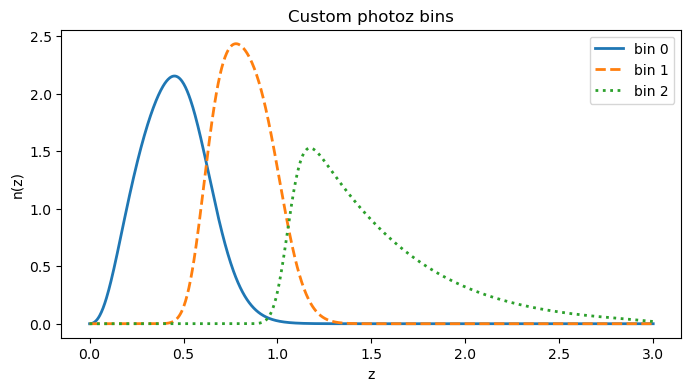

In [12]:
t = NZTomography()
z = np.linspace(0, 3, 1000)
nz = t.nz_model("smail", z, z0=0.26, alpha=2.0, beta=0.94, normalize=True)

tomo_spec = {
    "kind": "photoz",
    "nz": {"model": "arrays"},  # keep this until you implement the arrays-path defaulting
    "bins": {"scheme": "equipopulated", "n_bins": 3},
}

scatter_scale = [0.08, 0.05, 0.03]
mean_offset = [0.05, 0.02, 0.04]

tomo_spec["uncertainties"] = {
    "scatter_scale": scatter_scale,
    "mean_offset":   mean_offset,
}



payload = t.build_bins(z=z, nz=nz, tomo_spec=tomo_spec)

plot_parent_and_bins(z, nz, payload["bins"], title="Custom photoz bins")


In [8]:
def plot_parent_and_bins(z, nz, bins, *, title="NZTomography", ax=None, color=None, label_prefix="", linestyles=("-", "--", ":")):
    created = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))
        created = True

    # ax.plot(z, nz, linewidth=2, color="k", label="parent n(z)")

    for j, k in enumerate(sorted(bins.keys())):
        ls = linestyles[j % len(linestyles)]
        ax.plot(
            z,
            np.asarray(bins[k], float),
            linewidth=2,
            color=color,          # <-- same color for ALL bins in this run
            linestyle=ls,         # <-- differ bins by linestyle
            label=f"{label_prefix}bin {k}",
        )

    ax.set_xlabel("z")
    ax.set_ylabel("n(z)")
    ax.set_title(title)
    ax.legend()

    if created:
        plt.show()


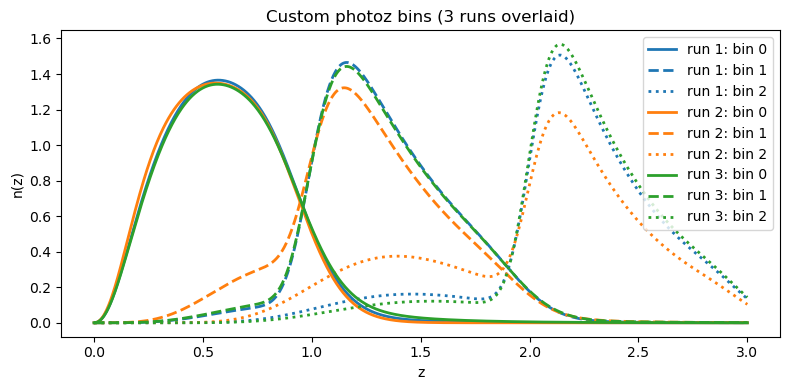

In [17]:

# --- build parent nz ---
t = NZTomography()
z = np.linspace(0, 3, 1000)
nz = t.nz_model("smail", z, z0=0.26, alpha=2.0, beta=0.94, normalize=True)

base_spec = {
    "kind": "photoz",
    "nz": {"model": "arrays"},
    "bins": {"scheme": "equidistant", "n_bins": 3},
    # REQUIRED core photo-z uncertainty params:
    "uncertainties": {
        "scatter_scale": [0.08, 0.05, 0.03],
        "mean_offset":   [0.01, 0.02, 0.03],
    },
}

runs = [
    {
        "outlier_frac": [0.10, 0.10, 0.10],
        "outlier_scatter_scale": [0.30, 0.30, 0.30],
        "outlier_mean_scale": [1.0, 1.0, 1.0],
        "outlier_mean_offset": [0.0, 0.0, 0.0],
    },
    {
        "outlier_frac": [0.15, 0.30, 0.20],
        "outlier_scatter_scale": [0.30, 0.30, 0.30],
        "outlier_mean_scale": [3.05, 1.10, 1.15],
        "outlier_mean_offset": [0.0, 0.0, 0.0],
    },
    {
        "outlier_frac": [0.20, 0.15, 0.12],
        "outlier_scatter_scale": [0.30, 0.30, 0.30],
        "outlier_mean_scale": [0.90, 0.85, 0.80],
        "outlier_mean_offset": [0.0, 0.0, 0.0],
    },
]

colors = ["C0", "C1", "C2"]

fig, ax = plt.subplots(figsize=(8, 4))

for i, (u, c) in enumerate(zip(runs, colors), start=1):
    spec = deepcopy(base_spec)

    # IMPORTANT: merge base uncertainties with per-run overrides
    spec["uncertainties"] = {**base_spec["uncertainties"], **u}

    payload = t.build_bins(z=z, nz=nz, tomo_spec=spec)
    plot_parent_and_bins(
        z, nz, payload["bins"],
        ax=ax,
        color=c,
        label_prefix=f"run {i}: ",
        title="Custom photoz bins (3 runs overlaid)",
    )

plt.tight_layout()
plt.show()


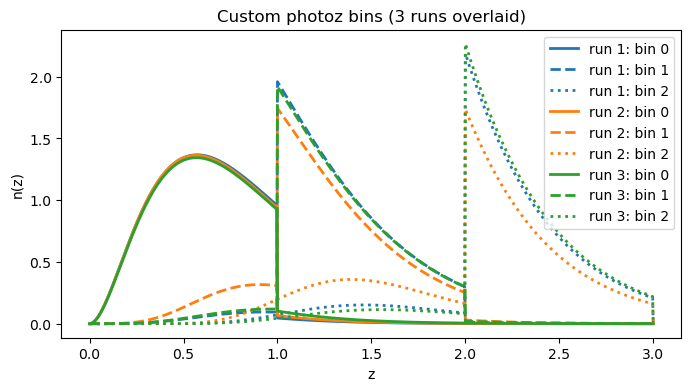

In [11]:


fig, ax = plt.subplots(figsize=(8, 4))

for i, (u, c) in enumerate(zip(runs, colors), start=1):
    spec = deepcopy(base_spec)
    spec["uncertainties"] = u

    payload = t.build_bins(z=z, nz=nz, tomo_spec=spec)

    plot_parent_and_bins(
        z, nz, payload["bins"],
        ax=ax,
        color=c,
        label_prefix=f"run {i}: ",
        title="Custom photoz bins (3 runs overlaid)",
    )
